# 📊 Exploratory Data Analysis (EDA) — Demo Notebook
### Based on the Auto-MPG Dataset (UCI Repository)

**What is EDA?**  
Exploratory Data Analysis is the process of examining a dataset to:
- Understand its structure and contents
- Detect patterns, anomalies and outliers
- Test assumptions using visual and statistical summaries
- Generate hypotheses for further analysis

This notebook walks through **every EDA step** with explanations and code.

---
**Dataset:** Auto-MPG Data | 398 rows × 9 columns  
**Goal:** Understand what drives fuel efficiency (mpg) in cars


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# ── Visual settings ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)
print("Libraries loaded ✓")


Libraries loaded ✓


## 2. Load & Inspect the Data
We load the Auto-MPG CSV and take a first look at shape, dtypes and sample rows.


In [23]:
# ── Download directly from UCI ─────────────────────────────────────────────
url = ("https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data")

col_names = ['mpg','cylinders','displacement','horsepower','weight',
             'acceleration','model_year','origin','car_name']

df = pd.read_csv(url, names=col_names, sep=r'\s+', na_values='?')
print("Shape:", df.shape)
df.head()


Shape: (398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8,307.0,130.0,3504.0,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693.0,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436.0,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433.0,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449.0,10.5,70,1,ford torino


In [3]:
# dtype & memory info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
 6   model_year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car_name      398 non-null    object 
dtypes: float64(5), int64(3), object(1)
memory usage: 28.1+ KB


In [4]:
# Basic descriptive statistics
df.describe()


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
count,398.000000,398.000000,398.000000,392.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,104.469388,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,38.491160,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,75.000000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,93.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,126.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000,3.000000


## 3. Pre-Processing
Steps:
1. Handle missing values
2. Remove duplicates
3. Fix data-types (cylinders, model_year → categorical)
4. Clean string columns


In [24]:
# ── Missing values ────────────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nNaN rows = {df.isnull().any(axis=1).sum()} "
      f"({df.isnull().any(axis=1).mean()*100:.2f}% of data)")

# Only ~1.5% → safe to drop
df.dropna(inplace=True)
print("\nAfter dropping NaN rows:", df.shape)


Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

NaN rows = 6 (1.51% of data)

After dropping NaN rows: (392, 9)


In [6]:
# ── Duplicates ────────────────────────────────────────────────────────────
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)


Duplicate rows: 0


In [25]:
# ── Type conversion ───────────────────────────────────────────────────────
# cylinders & model_year have very few unique values → treat as categorical
df['cylinders']   = df['cylinders'].astype('category')
df['model_year']  = df['model_year'].astype('category')
df['origin']      = df['origin'].map({1:'usa', 2:'europe', 3:'japan'})

# Clean string column
df['car_name'] = df['car_name'].str.strip().str.lower()
print("Updated dtypes:\n", df.dtypes)


Updated dtypes:
 mpg              float64
cylinders       category
displacement     float64
horsepower       float64
weight           float64
acceleration     float64
model_year      category
origin            object
car_name          object
dtype: object


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float64 
 1   cylinders     392 non-null    category
 2   displacement  392 non-null    float64 
 3   horsepower    392 non-null    float64 
 4   weight        392 non-null    float64 
 5   acceleration  392 non-null    float64 
 6   model_year    392 non-null    category
 7   origin        392 non-null    object  
 8   car_name      392 non-null    object  
dtypes: category(2), float64(5), object(2)
memory usage: 26.1+ KB


In [28]:
# ── Separate column lists ─────────────────────────────────────────────────
cat_cols = ['cylinders','origin','model_year']
num_cols = ['mpg','displacement','horsepower','weight','acceleration']
print("Categorical columns:", cat_cols)
print("Numerical columns  :", num_cols)


Categorical columns: ['cylinders', 'origin', 'model_year']
Numerical columns  : ['mpg', 'displacement', 'horsepower', 'weight', 'acceleration']


## 4. Feature Engineering
We create two helper features:
- **`mpg_level`** – bins mpg into low / medium / high (useful for group-based plots)
- **`car_company`** – extracts brand name from car_name


In [29]:
# mpg_level
df['mpg_level'] = pd.cut(df['mpg'],
                          bins=[0, 17, 29, df['mpg'].max()+1],
                          labels=['low','medium','high'],
                          right=False)

# car_company
df['car_company'] = df['car_name'].str.split().str[0]

print("New features added:")
print(df[['mpg','mpg_level','car_name','car_company']].head(8))


New features added:
    mpg mpg_level                   car_name car_company
0  18.0    medium  chevrolet chevelle malibu   chevrolet
1  15.0       low          buick skylark 320       buick
2  18.0    medium         plymouth satellite    plymouth
3  16.0       low              amc rebel sst         amc
4  17.0    medium                ford torino        ford
5  15.0       low           ford galaxie 500        ford
6  14.0       low           chevrolet impala   chevrolet
7  14.0       low          plymouth fury iii    plymouth


## 5. EDA — Categorical Attributes
**Goal:** Understand distribution and relationships of categorical features.  
Ideal distribution = **uniform** (equal counts across categories).


/tmp/ipykernel_173/4148010876.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette='Set2')
/tmp/ipykernel_173/4148010876.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette='Set2')
/tmp/ipykernel_173/4148010876.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, ax=ax, palette='Set2')
/tmp/ipykernel_173/4148010876.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0

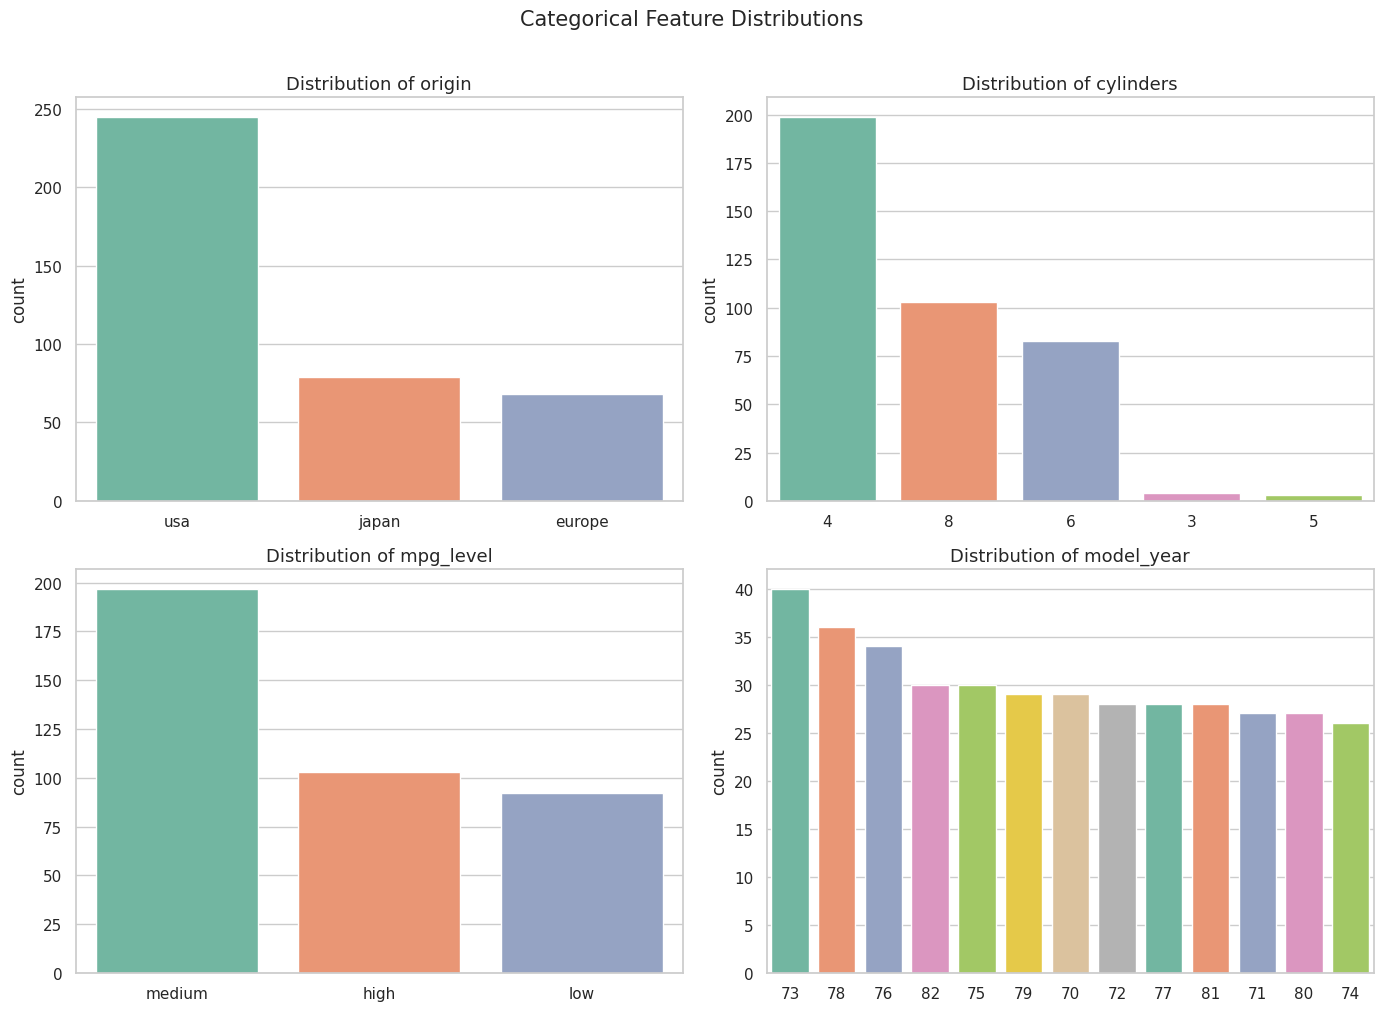

In [30]:
# ── Distribution of each categorical column ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cat_plot_cols = ['origin','cylinders','mpg_level','model_year']

for ax, col in zip(axes.flat, cat_plot_cols):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {col}', fontsize=13)
    ax.set_xlabel('')

plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()


In [31]:
# ── Proportion of dominant class ────────────────────────────────────────
for col in ['origin','cylinders','mpg_level']:
    top = df[col].value_counts(normalize=True).iloc[0]
    print(f"{col}: dominant class = '{df[col].value_counts().index[0]}' → {top*100:.1f}%")


origin: dominant class = 'usa' → 62.5%
cylinders: dominant class = '4' → 50.8%
mpg_level: dominant class = 'medium' → 50.3%


origin     europe  japan  usa
cylinders                    
3               0      4    0
4              61     69   69
5               3      0    0
6               4      6   73
8               0      0  103


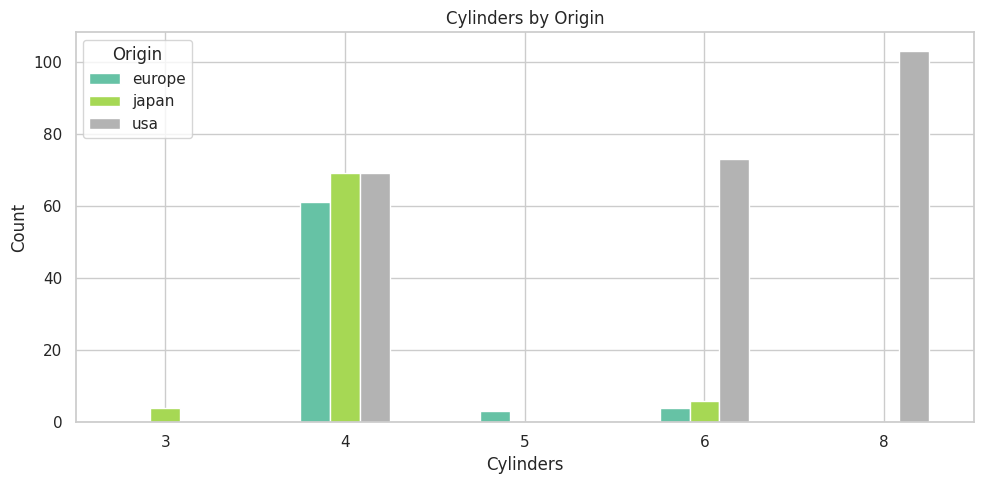

In [32]:
# ── Cross-tab: cylinders × origin ────────────────────────────────────────
# Insight: which cylinder counts appear in which regions?
ct = pd.crosstab(df['cylinders'], df['origin'])
print(ct)

ct.plot(kind='bar', figsize=(10,5), colormap='Set2')
plt.title('Cylinders by Origin')
plt.xlabel('Cylinders'); plt.ylabel('Count')
plt.xticks(rotation=0); plt.legend(title='Origin')
plt.tight_layout(); plt.show()


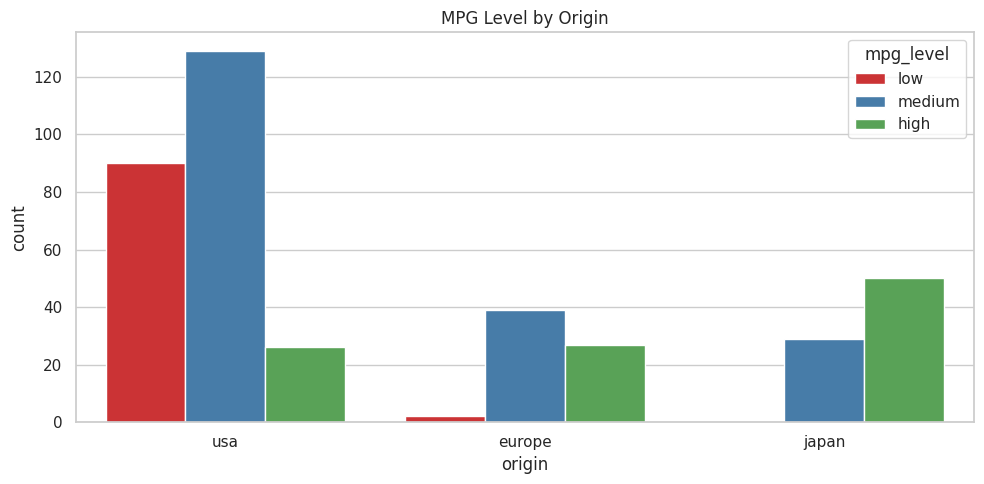

In [33]:
# ── mpg_level × origin ───────────────────────────────────────────────────
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='origin', hue='mpg_level',
              order=['usa','europe','japan'],
              hue_order=['low','medium','high'], palette='Set1')
plt.title('MPG Level by Origin')
plt.tight_layout(); plt.show()


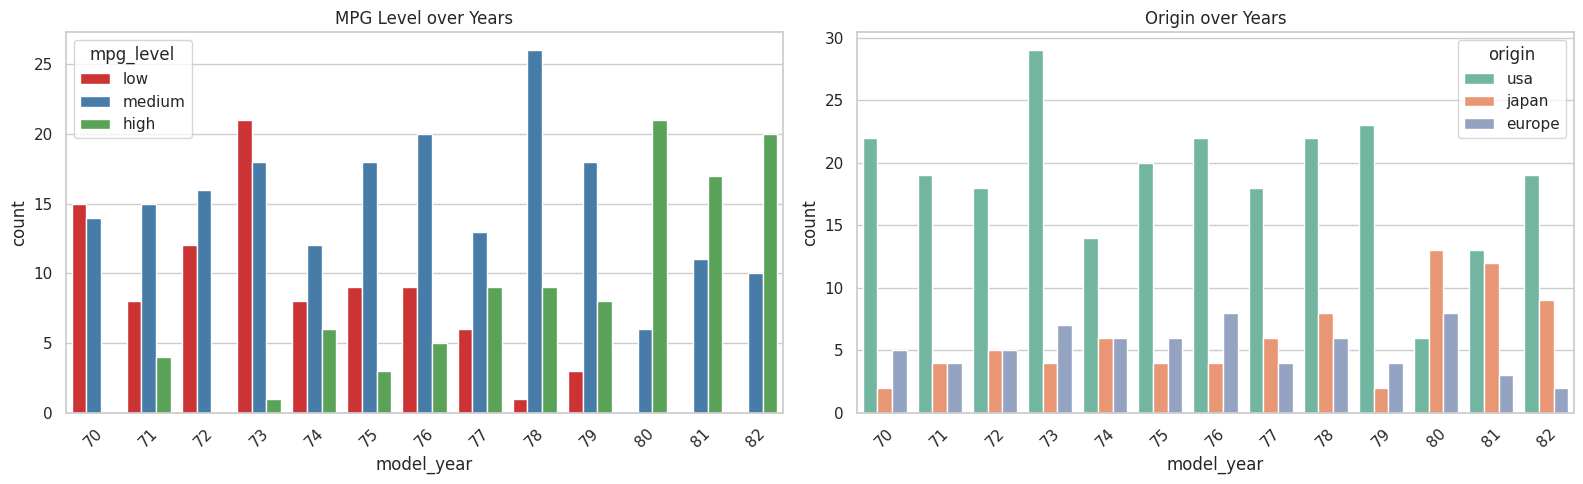

In [34]:
# ── Trend over model_year ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# mpg_level vs year
sns.countplot(data=df, x='model_year', hue='mpg_level',
              hue_order=['low','medium','high'],
              palette='Set1', ax=axes[0])
axes[0].set_title('MPG Level over Years')
axes[0].tick_params(axis='x', rotation=45)

# origin vs year
sns.countplot(data=df, x='model_year', hue='origin',
              palette='Set2', ax=axes[1])
axes[1].set_title('Origin over Years')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout(); plt.show()


## 6. EDA — Numerical Attributes
**Goal:** Understand distribution, spot outliers, and examine correlations.  
Ideal distribution = **Gaussian (bell curve)**.


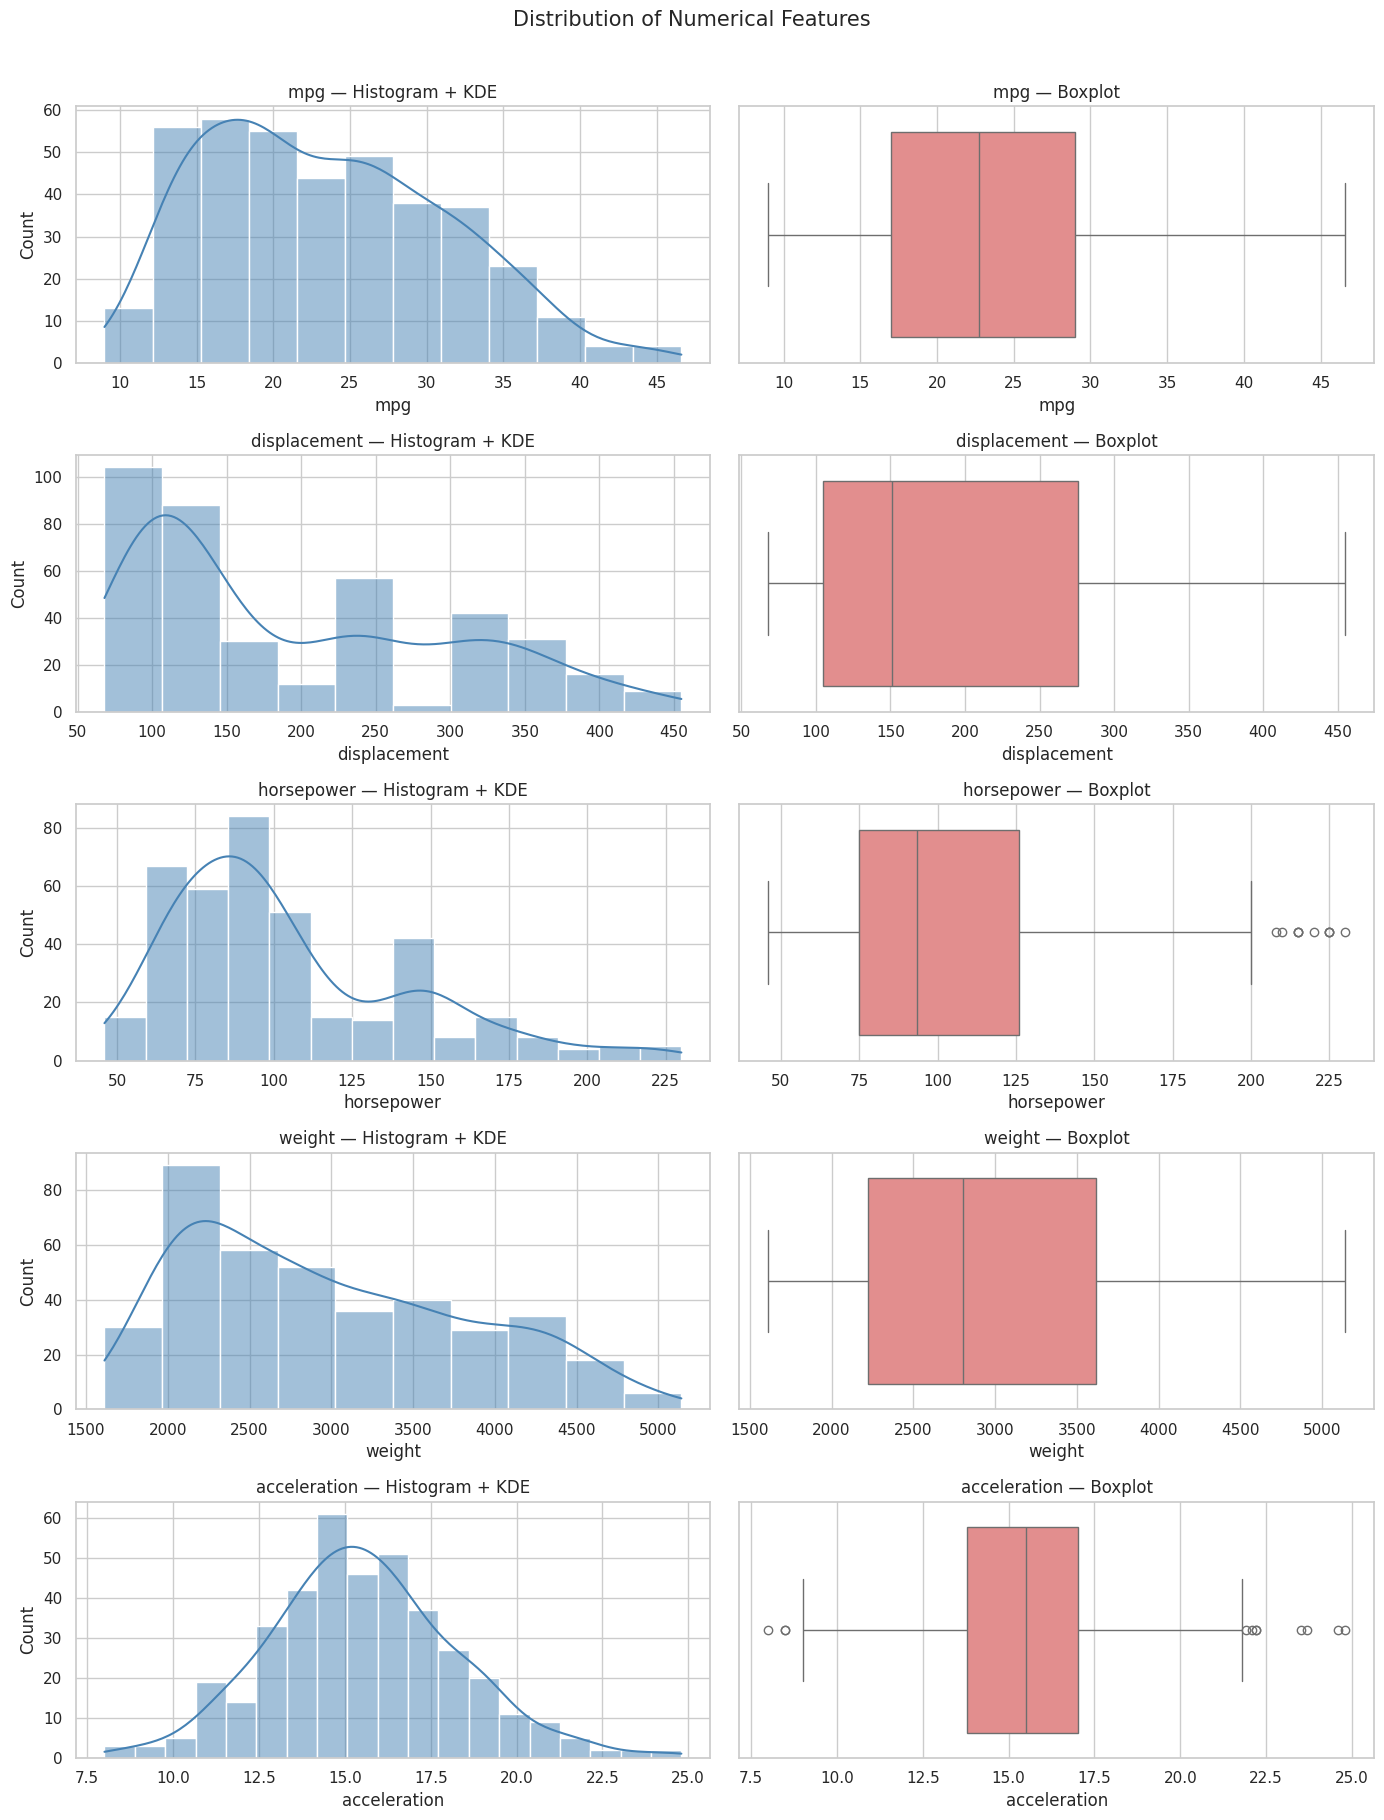

In [35]:
# ── Distributions: hist + KDE + boxplot ──────────────────────────────────
fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, 18))

for i, col in enumerate(num_cols):
    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[i][0], color='steelblue')
    axes[i][0].set_title(f'{col} — Histogram + KDE')
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i][1], color='lightcoral')
    axes[i][1].set_title(f'{col} — Boxplot')

plt.suptitle('Distribution of Numerical Features', fontsize=15, y=1.01)
plt.tight_layout(); plt.show()


In [36]:
# ── Outlier detection using Tukey (IQR) method ───────────────────────────
def tukey_outliers(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    mask = (series < Q1 - 1.5*IQR) | (series > Q3 + 1.5*IQR)
    return series[mask]

print("=== Outlier counts (Tukey/IQR method) ===")
for col in num_cols:
    n = len(tukey_outliers(df[col]))
    print(f"  {col:15s}: {n} outliers")


=== Outlier counts (Tukey/IQR method) ===
  mpg            : 0 outliers
  displacement   : 0 outliers
  horsepower     : 10 outliers
  weight         : 0 outliers
  acceleration   : 11 outliers


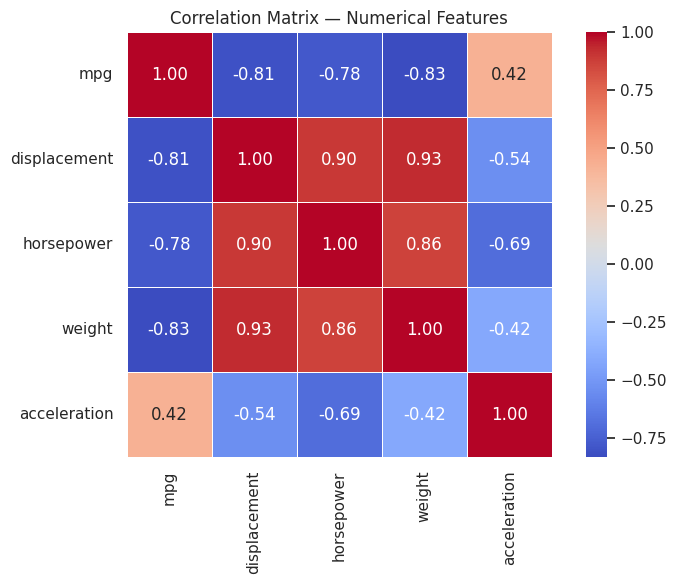


Key correlations with mpg:
weight         -0.832244
displacement   -0.805127
horsepower     -0.778427
acceleration    0.423329
mpg             1.000000
Name: mpg, dtype: float64


In [37]:
# ── Correlation heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(8,6))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout(); plt.show()

print("\nKey correlations with mpg:")
print(corr['mpg'].sort_values())


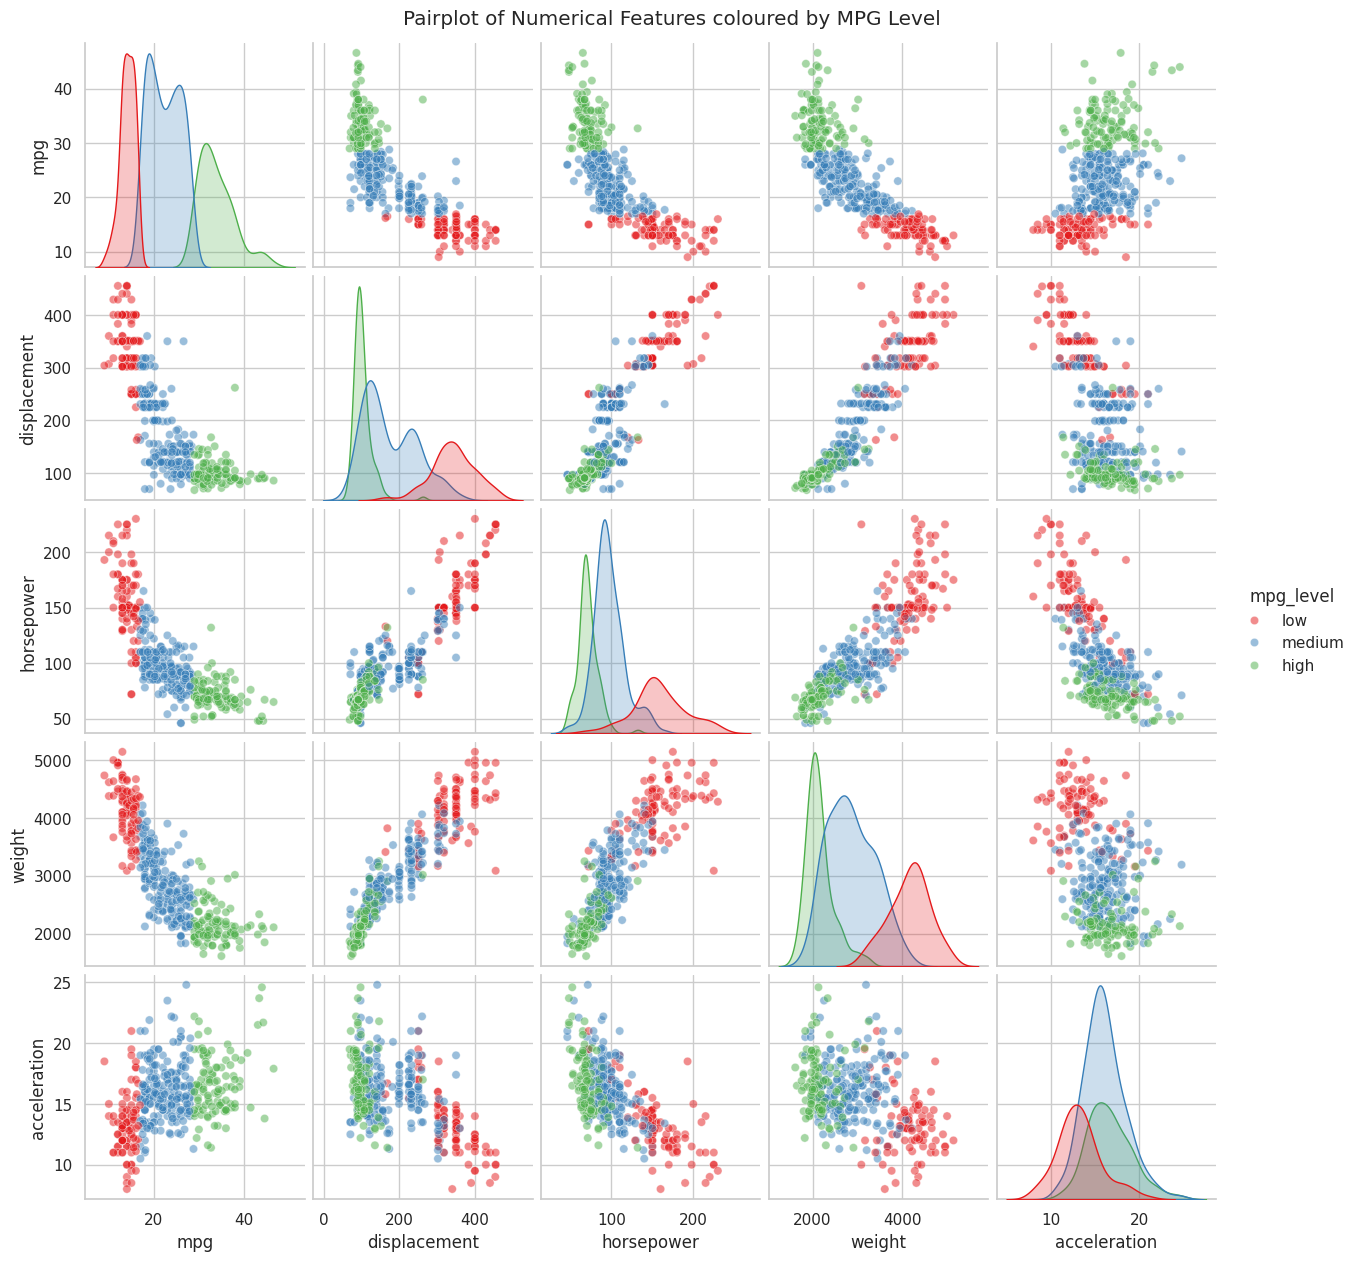

In [38]:
# ── Pairplot ──────────────────────────────────────────────────────────────
sns.pairplot(df[num_cols + ['mpg_level']], hue='mpg_level',
             hue_order=['low','medium','high'],
             plot_kws={'alpha':0.5}, palette='Set1')
plt.suptitle('Pairplot of Numerical Features coloured by MPG Level', y=1.01)
plt.show()


## 7. Numerical vs Categorical — Relationships
Boxplots and violin plots reveal how numerical values shift across categories.


/tmp/ipykernel_173/2800230373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='origin', y=col,
/tmp/ipykernel_173/2800230373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='origin', y=col,
/tmp/ipykernel_173/2800230373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='origin', y=col,
/tmp/ipykernel_173/2800230373.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same e

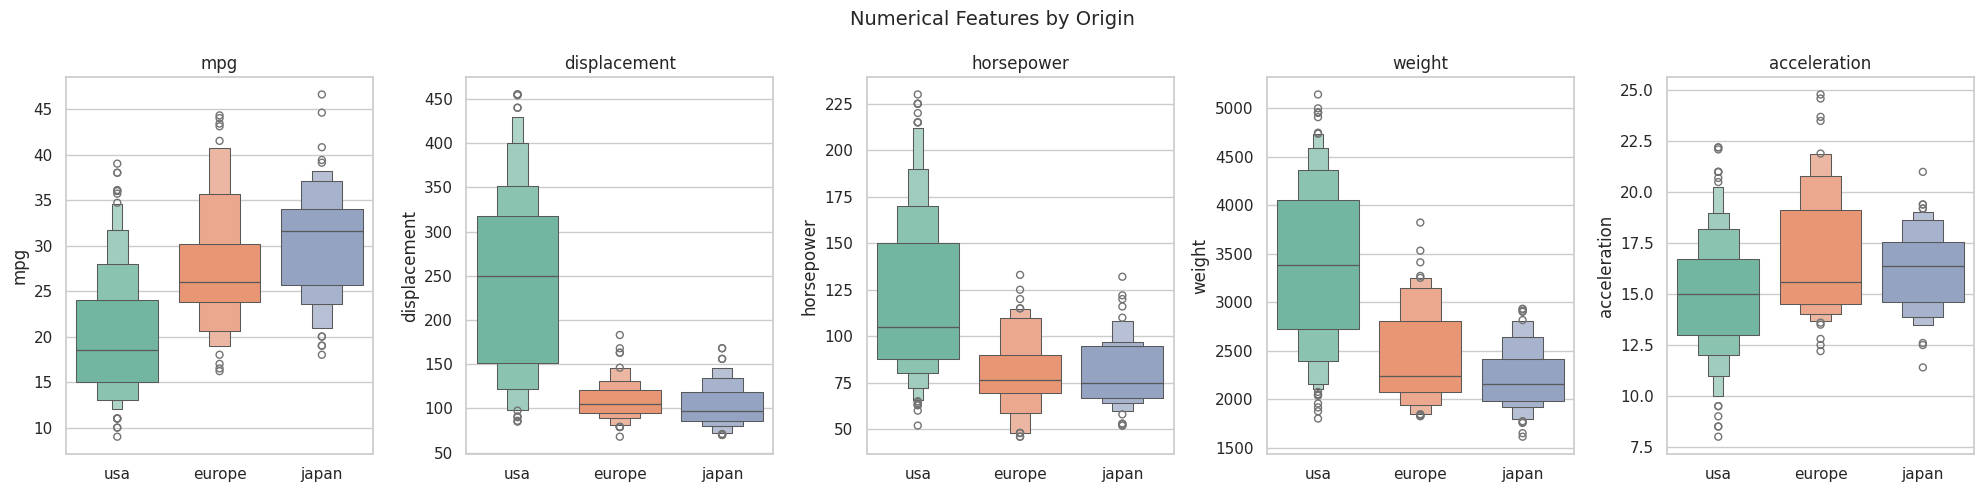

In [39]:
# ── Numerical features by origin ─────────────────────────────────────────
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 5))
for ax, col in zip(axes, num_cols):
    sns.boxenplot(data=df, x='origin', y=col,
                  order=['usa','europe','japan'], palette='Set2', ax=ax)
    ax.set_title(col); ax.set_xlabel('')
plt.suptitle('Numerical Features by Origin', fontsize=14)
plt.tight_layout(); plt.show()


/tmp/ipykernel_173/1246851046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='mpg_level', y=col,
/tmp/ipykernel_173/1246851046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='mpg_level', y=col,
/tmp/ipykernel_173/1246851046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='mpg_level', y=col,
/tmp/ipykernel_173/1246851046.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` fo

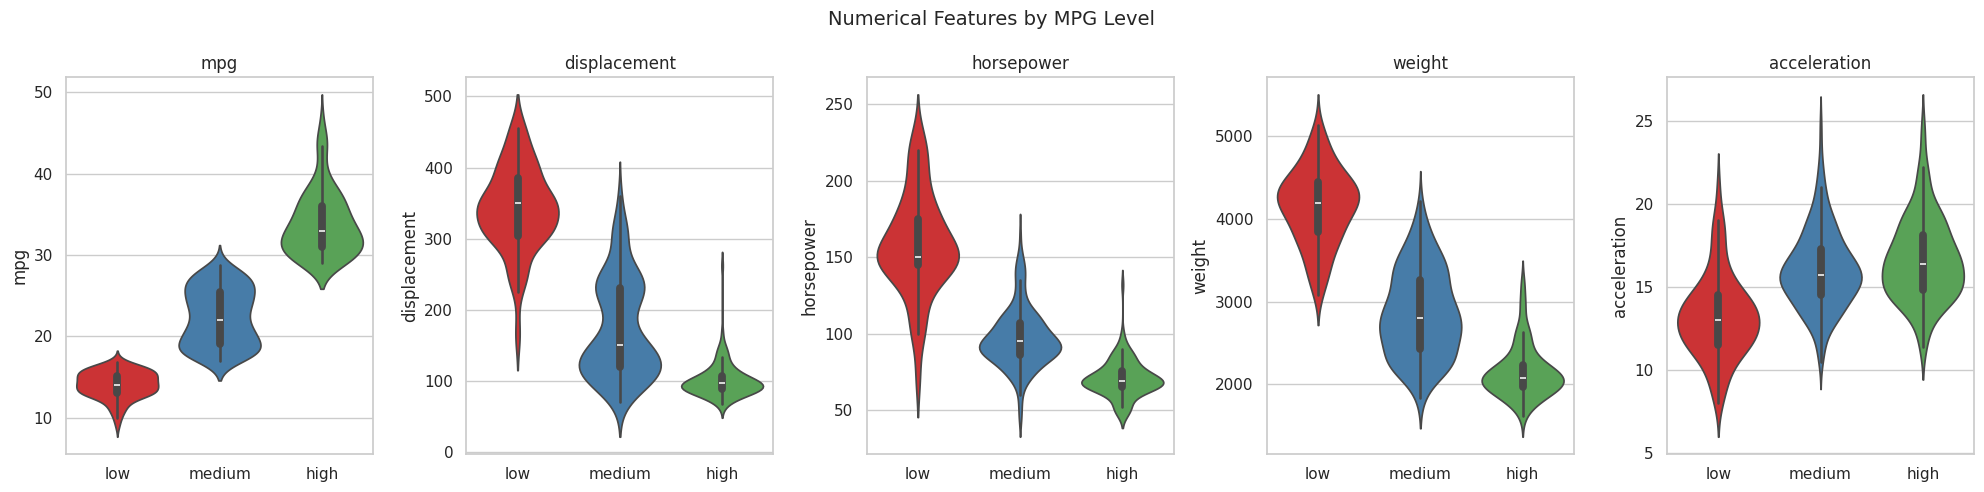

In [20]:
# ── Numerical features by mpg_level ──────────────────────────────────────
fig, axes = plt.subplots(1, len(num_cols), figsize=(20, 5))
for ax, col in zip(axes, num_cols):
    sns.violinplot(data=df, x='mpg_level', y=col,
                   order=['low','medium','high'], palette='Set1', ax=ax)
    ax.set_title(col); ax.set_xlabel('')
plt.suptitle('Numerical Features by MPG Level', fontsize=14)
plt.tight_layout(); plt.show()


/tmp/ipykernel_173/73407641.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mpg_year = df.groupby('model_year')['mpg'].mean()


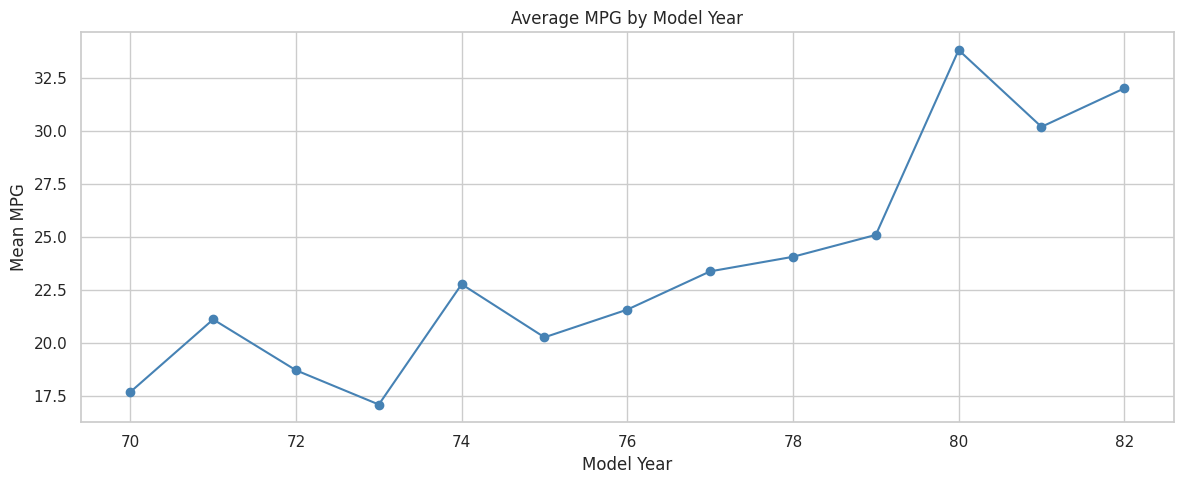

In [21]:
# ── MPG trend over model_year (line plot) ────────────────────────────────
plt.figure(figsize=(12,5))
mpg_year = df.groupby('model_year')['mpg'].mean()
mpg_year.plot(marker='o', color='steelblue')
plt.title('Average MPG by Model Year')
plt.xlabel('Model Year'); plt.ylabel('Mean MPG')
plt.tight_layout(); plt.show()


## 8. Key Insights Summary

| Category | Insight |
|---|---|
| **Origin** | USA dominates (~62%). Japan leads in fuel efficiency. |
| **Cylinders** | 4-cylinder cars dominate (50%+). 8-cylinder = low MPG. |
| **Model Year** | Newer cars have higher MPG; 8-cyl cars disappear after '79. |
| **Horsepower** | Strong **negative** correlation with MPG (r ≈ -0.78). |
| **Weight** | Strong **negative** correlation with MPG (r ≈ -0.83). |
| **Acceleration** | Mild **positive** correlation with MPG. |
| **Displacement** | Strong **negative** correlation with MPG (r ≈ -0.80). |
| **Car Company** | Ford & Chevrolet alone = ~23% of dataset; all top brands are USA. |

> **Next Steps:** Statistical hypothesis testing (Part 2) and predictive modelling (Part 3).
